In [1]:
!pip install playwright

In [2]:
!playwright install firefox

In [ ]:
# #用指令來下載ttf檔(字型檔)
# !wget -O taipei_sans_tc_beta.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

--2025-01-22 15:29:05--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 74.125.134.100, 74.125.134.102, 74.125.134.113, ...
Connecting to drive.google.com (drive.google.com)|74.125.134.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2025-01-22 15:29:05--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.139.132, 2607:f8b0:400c:c05::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.139.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘taipei_sans_tc_beta.ttf’

taipei_sans_tc_beta 100%[===================>]  19.70M  50.9MB/s    in 0.4s    

2025-01-22 15:29:13 (5

## 匯入packages

In [6]:
from playwright.async_api import async_playwright, Page, expect, Locator, BrowserContext
import re
import numpy as np
# from bs4 import BeautifulSoup as BS
import asyncio
from matplotlib import pyplot as plt
from matplotlib.font_manager import fontManager
import matplotlib as mpl
import pandas as pd
import os

## 全域變數定義

In [7]:
stock_abbr='ASML'
# has_inventories=False
process_num=8  # 從morningstar網站取得資料，全部都按照每一季整理好，無須自行處理

## 函數定義

In [8]:
# Plotting function
# Like "American Stock Analysis", plotting results shall depend on company whether it has inventories or not
def plot_results(financial_data_dict:dict):
  print(f'Start plotting financial indicators of {financial_data_dict["Company"]}\t')

  # Company;s name
  company_name=financial_data_dict["Company"]

  # Check company's inventories
  inv=True if "Inventories" in financial_data_dict.keys() else False
  # print(inv)

  # Get x-label (year+quarter) info
  x=financial_data_dict["Quarter"]
  x_temp=np.arange(len(x)) # For substituting x-label

  # Company with inventories
  if inv:
    # Figure 1: Liabilities and stockholder's equity, stacked barchart (liabilities + equity = assets)
    fig1=plt.subplot(111)

    Liabilities=financial_data_dict["Liabilities"]
    Equity=financial_data_dict["Equity"]

    plt.bar(x_temp,Liabilities,color="blue",width=0.5,label="Liabilities")
    plt.bar(x_temp,Equity,color="green",width=0.5,label="Equity",bottom=Liabilities)
    plt.title(f"{company_name}\nLiabilities and Equity",fontsize=18)
    plt.xticks(rotation=45)
    plt.xticks(x_temp,x)
    plt.ylabel("NTD")
    plt.legend(bbox_to_anchor=(1.02,0.7),loc="upper left")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.6)
    plt.show()

    # Figure 2: Cash flow, stacked barchart
    fig2=plt.subplot(111)

    Operating=financial_data_dict["CashFlowFromOperatingActivities"]
    Investing=financial_data_dict["CashFlowFromInvestingActivities"]
    Financing=financial_data_dict["CashFlowFromFinancingActivities"]

    plt.bar(x_temp,Operating,color="blue",label="Net cash flow from\noperating activities",width=0.5)

    # Stack upward (positive) or downward (negative) based on the sign of value
    # Two baselines for recording positive and negative values of cash flows
    baseline_positive=[]
    baseline_negative=[]

    for o in Operating:
      if o>=0:
        baseline_positive.append(o)
        baseline_negative.append(0)
      else:
        baseline_positive.append(0)
        baseline_negative.append(o)

    baseline_for_investing=[baseline_positive[idx] if i>=0 else baseline_negative[idx] for idx,i in enumerate(Investing)]
    plt.bar(x_temp,Investing,color="green",label="Net cash flow from\ninvesting activities",width=0.5,bottom=baseline_for_investing)

    for idx,i in enumerate(Investing):
      if i>=0:
        baseline_positive[idx]+=i
      else:
        baseline_negative[idx]+=i

    baseline_for_financing=[baseline_positive[idx] if f>=0 else baseline_negative[idx] for idx,f in enumerate(Financing)]
    plt.bar(x_temp,Financing,color="gray",label="Net cash flow from\nfinancing activities",width=0.5,bottom=baseline_for_financing)

    plt.title(f"{company_name}\nCash flows",fontsize=18)
    plt.xticks(rotation=45)
    plt.xticks(x_temp,x)
    plt.ylabel("NTD")
    plt.legend(bbox_to_anchor=(1.02,0.7),loc="upper left")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.6)
    plt.show()

    # Figure 3: Operating circumstances
    fig3=plt.subplot(111)
    plt.xticks(rotation=45)  # Need to place this setting before plotting or interpreter will confuse

    Revenue=financial_data_dict["Revenue"]
    GrossProfit=financial_data_dict["GrossProfit"]
    ProfitLoss=financial_data_dict["ProfitLoss"]
    OtherIncome=financial_data_dict["OtherIncome"]
    # OtherIncome=np.array(ComprehensiveIncome)-np.array(ProfitLoss)
    DaysSalesOfInventories=financial_data_dict["DaysSalesOfInventories"]

    br1=plt.bar(x_temp-0.3,Revenue,color="blue",label="Revenue",width=0.6,alpha=0.85)
    br2=plt.bar(x_temp-0.2,GrossProfit,color="green",label="Gross profit",width=0.6,alpha=0.85)
    br3=plt.bar(x_temp-0.1,ProfitLoss,color="orange",label="Profit loss",width=0.6,alpha=0.85)
    br4=plt.bar(x_temp+0.2,OtherIncome,color="brown",label="Other income",width=0.6,alpha=0.85,zorder=1)

    # Double y-axis
    fig3_1=fig3.twinx()
    ln1=fig3_1.plot(x_temp,DaysSalesOfInventories,color="red",marker="D",label="Days sales of inventories")

    plt.xticks(x_temp,x)
    plt.title(f"{company_name}\nOperating circumstances",fontsize=18)
    fig3.set_ylabel("NTD")
    fig3_1.set_ylabel("Days")
    brs_lns=[br1,br2,br3,br4]+(ln1)
    plt.legend(handles = brs_lns, bbox_to_anchor=(1.2,0.7), loc='upper left')
    plt.grid(axis="y")
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.6)
    plt.show()

    # Figure 4: Competitiveness
    GrossMargin=financial_data_dict["GrossMargin"]
    OperatingMargin=financial_data_dict["OperatingMargin"]
    ProfitLossMargin=financial_data_dict["ProfitLossMargin"]

    fig4=plt.subplot(111)
    fig4.plot(x_temp,GrossMargin,color="blue",marker="o",label="Gross margin(%)")
    fig4.plot(x_temp,OperatingMargin,color="green",marker="o",label="Operating margin(%)")
    fig4.plot(x_temp,ProfitLossMargin,color="orange",marker="o",label="Profitloss margin(%)")

    plt.title(f"{company_name}\nCompetitiveness",fontsize=18)
    plt.ylabel("%")
    plt.xticks(x_temp,x)
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.02,0.7), loc='upper left')
    plt.grid(axis="y")
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.6)
    plt.show()

    # Figure 5: Investment return
    fig5=plt.subplot(111)
    plt.xticks(rotation=45)

    BasicEarningsLossPerShare=financial_data_dict["BasicEPS"]
    DilutedEarningsLossPerShare=financial_data_dict["DilutedEPS"]
    ROA=financial_data_dict["ROA"]
    ROE=financial_data_dict["ROE"]

    ln1=plt.plot(x_temp,BasicEarningsLossPerShare,color="blue",marker="D",label="Earning per share\n(basic)")
    ln2=plt.plot(x_temp,DilutedEarningsLossPerShare,color="green",marker="D",label="Earning per share\n(diluted)")

    fig5_1=fig5.twinx()
    ln3=fig5_1.plot(x_temp,ROA,color="orange",marker="D",label="Return on assets")
    ln4=fig5_1.plot(x_temp,ROE,color="brown",marker="D",label="Return on equity")

    plt.xticks(x_temp,x)
    plt.title(f"{company_name}\nInvestment return",fontsize=18)
    fig5.set_ylabel("EPS (NTD)")
    fig5_1.set_ylabel("Return (%)")
    lns=ln1+ln2+ln3+ln4
    plt.legend(handles=lns,bbox_to_anchor=(1.2,0.7), loc='upper left')
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

  # Company without inventories
  else:
    # Figure 1: Liabilities and stockholder's equity, stacked barchart (liabilities + equity = assets)
    fig1=plt.subplot(111)

    Liabilities=financial_data_dict["Liabilities"]
    Equity=financial_data_dict["Equity"]
    TotalInvestment=financial_data_dict["TotalInvestment"]
    RiskWeightedAssets=financial_data_dict["RiskWeightedAssets"]

    plt.bar(x_temp-0.2,Liabilities,color="blue",width=0.5,label="Liabilities")
    plt.bar(x_temp-0.2,Equity,color="green",width=0.5,label="Equity",bottom=Liabilities)
    plt.bar(x_temp,TotalInvestment,color="orange",width=0.5,label="Total investment")
    plt.bar(x_temp,RiskWeightedAssets,color="red",width=0.5,label="Risk weighted assets")

    plt.title(f"{company_name}\nLiabilities and Equity",fontsize=18)
    plt.xticks(rotation=45)
    plt.xticks(x_temp,x)
    plt.ylabel("NTD")
    plt.legend(bbox_to_anchor=(1.02,0.7),loc="upper left")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.6)
    plt.show()

    # Figure 2: Cash flow, stacked barchart
    fig2=plt.subplot(111)

    Operating=financial_data_dict["CashFlowFromOperatingActivities"]
    Investing=financial_data_dict["CashFlowFromInvestingActivities"]
    Financing=financial_data_dict["CashFlowFromFinancingActivities"]

    plt.bar(x_temp,Operating,color="blue",label="Net cash flow from\noperating activities",width=0.5)

    # Stack upward (positive) or downward (negative) based on the sign of value
    # Two baselines for recording positive and negative values of cash flows
    baseline_positive=[]
    baseline_negative=[]

    for o in Operating:
      if o>=0:
        baseline_positive.append(o)
        baseline_negative.append(0)
      else:
        baseline_positive.append(0)
        baseline_negative.append(o)

    baseline_for_investing=[baseline_positive[idx] if i>=0 else baseline_negative[idx] for idx,i in enumerate(Investing)]
    plt.bar(x_temp,Investing,color="green",label="Net cash flow from\ninvesting activities",width=0.5,bottom=baseline_for_investing)

    for idx,i in enumerate(Investing):
      if i>=0:
        baseline_positive[idx]+=i
      else:
        baseline_negative[idx]+=i

    baseline_for_financing=[baseline_positive[idx] if f>=0 else baseline_negative[idx] for idx,f in enumerate(Financing)]
    plt.bar(x_temp,Financing,color="gray",label="Net cash flow from\nfinancing activities",width=0.5,bottom=baseline_for_financing)

    plt.title(f"{company_name}\nCash flows",fontsize=18)
    plt.xticks(rotation=45)
    plt.xticks(x_temp,x)
    plt.ylabel("NTD")
    plt.legend(bbox_to_anchor=(1.02,0.7),loc="upper left")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.6)
    plt.show()

    # Figure 3: Operating circumstances
    fig3=plt.subplot(111)
    plt.xticks(rotation=45)
    plt.grid(axis="y")

    NetIncomeLoss=financial_data_dict["Revenue"]
    GrossProfit=financial_data_dict["GrossProfit"]
    ProfitLoss=financial_data_dict["ProfitLoss"]
    OtherIncome=financial_data_dict["OtherIncome"]
    # OtherIncome=np.array(ComprehensiveIncome)-np.array(ProfitLoss)
    NonPerformingLoansRatio=financial_data_dict["NonPerformingLoansRatio"]
    CapitalAdequacyRatio=financial_data_dict["CapitalAdequacyRatio"]
    CoverageRatio=financial_data_dict["CoverageRatio"]

    br1=plt.bar(x_temp-0.2,NetIncomeLoss,color="blue",label="Net income loss",width=0.6)
    br2=plt.bar(x_temp-0.1,GrossProfit,color="green",label="Gross profit",width=0.6)
    br3=plt.bar(x_temp,ProfitLoss,color="orange",label="Profit loss",width=0.6)
    br4=plt.bar(x_temp+0.2,OtherIncome,color="brown",label="Other income",width=0.6)

    # Double y-axis
    fig3_1=fig3.twinx()
    ln1=fig3_1.plot(x_temp,NonPerformingLoansRatio,color="red",marker="D",label="Non-performing \nloans ratio")
    ln2=fig3_1.plot(x_temp,CapitalAdequacyRatio,color="purple",marker="D",label="Capital adequacy\nratio")
    ln3=fig3_1.plot(x_temp,CoverageRatio,color="pink",marker="D",label="Coverage ratio")

    plt.xticks(x_temp,x)
    plt.title(f"{company_name}\nOperating circumstances",fontsize=18)
    fig3.set_ylabel("NTD")
    fig3_1.set_ylabel("%")
    brs_lns=[br1,br2,br3,br4]+(ln1)+(ln2)+(ln3)
    plt.legend(handles=brs_lns, bbox_to_anchor=(1.2,0.7), loc='upper left')
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.6)
    plt.show()

    # Figure 4: Competitiveness
    fig4=plt.subplot(111)

    GrossMargin=financial_data_dict["GrossMargin"]
    OperatingMargin=financial_data_dict["OperatingMargin"]
    ProfitLossMargin=financial_data_dict["ProfitLossMargin"]

    fig4.plot(x_temp,GrossMargin,color="blue",marker="o",label="Gross margin(%)")
    fig4.plot(x_temp,OperatingMargin,color="green",marker="o",label="Operating margin(%)")
    fig4.plot(x_temp,ProfitLossMargin,color="orange",marker="o",label="Profit loss margin(%)")

    plt.title(f"{company_name}\nCompetitiveness",fontsize=18)
    plt.xticks(rotation=45)
    plt.xticks(x_temp,x)
    plt.ylabel("%")
    plt.legend(bbox_to_anchor=(1.02,0.7),loc="upper left")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.6)
    plt.show()

    # Figure 5: Investment return
    fig5=plt.subplot(111)
    plt.xticks(rotation=45)

    BasicEarningsLossPerShare=financial_data_dict["BasicEPS"]
    DilutedEarningsLossPerShare=financial_data_dict["DilutedEPS"]
    ROA=financial_data_dict["ROA"]
    ROE=financial_data_dict["ROE"]

    ln1=plt.plot(x_temp,BasicEarningsLossPerShare,color="blue",marker="D",label="Earning per share\n(basic)")
    ln2=plt.plot(x_temp,DilutedEarningsLossPerShare,color="green",marker="D",label="Earning per share\n(diluted)")

    fig5_1=fig5.twinx()
    ln3=fig5_1.plot(x_temp,ROA,color="orange",marker="D",label="Return on assets")
    ln4=fig5_1.plot(x_temp,ROE,color="brown",marker="D",label="Return on equity")

    plt.xticks(x_temp,x)
    plt.title(f"{company_name}\nInvestment return",fontsize=18)
    fig5.set_ylabel("EPS (NTD)")
    fig5_1.set_ylabel("Return (%)")
    lns=ln1+ln2+ln3+ln4
    plt.legend(handles=lns,bbox_to_anchor=(1.2,0.7), loc='upper left')
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

# Get company's name or error
async def get_company_name(page:Page):
  error_message=page.get_by_text("404 Error")
  company_name=page.locator('css=div[id="security-title"]')
  await expect(company_name.or_(error_message).first).to_be_visible(timeout=30000)
  if (await error_message.is_visible()):
    print(f"Cannot find company with url '{page.url}. Try another url'")
    return False
  print(f"Find company with url '{page.url}'")
  return await company_name.locator('css=span[itemprop]').text_content()

# Annual to quarterly
async def annual_to_quarterly(page:Page):
  change_container=page.locator('css=div[class="mds-button-container__sal"]').first
  annual_quarterly_ul=page.get_by_role("tooltip", name="Annual Quarterly").get_by_role("list")
  await change_container.click()
  await expect(annual_quarterly_ul).to_be_visible()
  await annual_quarterly_ul.locator("xpath=/li[2]").click()
  await page.wait_for_timeout(3000)

  # Check if annual is selected
  current_mode=await change_container.text_content()
  current_mode=current_mode.strip()
  print(current_mode)
  if current_mode!="Quarterly":
    raise Exception("Report mode did not change to quarterly")

# Get specific data
def get_specific_data(row:str,quarter:str,dfs_rows:list,dfs:list):
  row_pattern=re.compile(f'{row}$')
  for d_r in dfs_rows:
    for r in d_r[1]:
      if re.search(row_pattern,r):
        temp=dfs[d_r[0]].loc[r,quarter]
        if isinstance(temp,pd.core.series.Series):
          temp=temp.iloc[0]
        return temp
  return np.nan



# Extract data from reports
def extract_data_from_reports(abbr,company_name):
  # Read balance sheet file and extract targeted data
  cur_dir=os.getcwd()
  folder_path=os.path.join(cur_dir,abbr)
  _,_,files=next(os.walk(folder_path))

  dfs=[]
  for f in files:
    df=pd.read_excel(os.path.join(folder_path,f),index_col=0)
    dfs.append(df)
  # print(dfs)
  df_rows=[]
  for idx,d in enumerate(dfs):
    df_rows.append((idx,d.index.to_list()))

  # print(dfs_rows[0])
  result_dict=dict()
  result_dict["Company"]=company_name
  result_dict["Quarter"]=dfs[0].columns.to_list()[-8:] if dfs[0].columns.to_list()[-1]!="TTM" else dfs[0].columns.to_list()[-9:-1]
  inv=any([re.search(r"Inventories$",index) for index in df_rows[0][1]]+  # Balance sheet
          [re.search(r"Inventories$",index) for index in df_rows[1][1]]+  # Cash flow
          [re.search(r"Inventories$",index) for index in df_rows[2][1]])  # Income statement
  print(f"Has inventories? {inv}")
  # print(get_specific_data("Total Assets","Q3 2024",df_rows,dfs))
  # Company with inventories
  if inv:
    result_dict["Assets"]=np.array([get_specific_data("Total Assets",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["Inventories"]=np.array([get_specific_data("Inventories",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["Liabilities"]=np.array([get_specific_data("Total Liabilities",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["Equity"]=np.array([get_specific_data("Total Equity",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["BasicEPS"]=np.array([get_specific_data("Basic EPS",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["DilutedEPS"]=np.array([get_specific_data("Diluted EPS",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["Revenue"]=np.array([get_specific_data("Total Revenue",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["GrossProfit"]=np.array([get_specific_data("Gross Profit",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["ProfitLossBeforeTax"]=np.array([get_specific_data("Total Operating Profit/Loss",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["ProfitLoss"]=np.array([get_specific_data("Net Income Available to Common Stockholders",q,df_rows,dfs) for q in result_dict["Quarter"]])  # 似乎已經跟業外收益綁在一起
    result_dict["OtherIncome"]=np.array([get_specific_data("Non-Operating Income/Expense, Total",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["CashFlowFromOperatingActivities"]=np.array([get_specific_data("Cash Flow from Operating Activities, Indirect",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["CashFlowFromInvestingActivities"]=np.array([get_specific_data("Cash Flow from Investing Activities",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["CashFlowFromFinancingActivities"]=np.array([get_specific_data("Cash Flow from Financing Activities",q,df_rows,dfs) for q in result_dict["Quarter"]])

    # Calculate several important indicator about company's performance
    # Gross margin = Gross profit / Revenue * 100(%)
    result_dict["GrossMargin"]=np.round(result_dict["GrossProfit"]/result_dict["Revenue"]*100,2)  # numpy會自行處理相關計算(分母為0則為inf)

    # Operating margin = ProfitLossBeforeTax / Revenue * 100(%)
    result_dict["OperatingMargin"]=np.round(result_dict["ProfitLossBeforeTax"]/result_dict["Revenue"]*100,2)

    # Profit loss margin (net income margin) = Profit loss / Revenue * 100(%)
    result_dict["ProfitLossMargin"]=np.round(result_dict["ProfitLoss"]/result_dict["Revenue"]*100,2)

    # Days sales of inventory = 365 * Inventories / (Revenue - GrossProfit)
    result_dict["DaysSalesOfInventories"]=np.round(365*result_dict["Inventories"]/(result_dict["Revenue"]-result_dict["GrossProfit"]),2)

    # Return on assets = Profit loss (net income) / Assets * 100(%)
    result_dict["ROA"]=np.round(result_dict["ProfitLoss"]/result_dict["Assets"]*100,2)

    # Return on equity = Profit loss (net income) / Equity * 100(%)
    result_dict["ROE"]=np.round(result_dict["ProfitLoss"]/result_dict["Equity"]*100,2)

  # Company without inventories
  else:
    # print(result_dict["Quarter"])
    result_dict["Assets"]=np.array([get_specific_data("Total Assets",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["Liabilities"]=np.array([get_specific_data("Total Liabilities",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["Equity"]=np.array([get_specific_data("Total Equity",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["RiskWeightedAssets"]=np.array([get_specific_data("Risk Weighted Assets",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["GrossLoans"]=np.array([get_specific_data("Gross Loans and Advances",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["AmountOfNon-PerformingLoans"]=np.abs(np.array([get_specific_data("Loan Loss Allowance/Adjustment",q,df_rows,dfs) for q in result_dict["Quarter"]]))
    result_dict["AllowanceForBadDebts-AssetQualityForBankSubsidiaries"]=np.abs(np.array([get_specific_data("Provision and Impairment for Loan Losses and Credit Risk",q,df_rows,dfs) for q in result_dict["Quarter"]]))
    result_dict["TotalInvestment"]=np.array([get_specific_data("Total Investments",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["BasicEPS"]=np.array([get_specific_data("Basic EPS",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["DilutedEPS"]=np.array([get_specific_data("Diluted EPS",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["Revenue"]=np.array([get_specific_data("Total Revenue",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["CostOfRevenue"]=np.abs(np.array([get_specific_data("Interest Expense, Cost of Revenue",q,df_rows,dfs) for q in result_dict["Quarter"]]))
    # result_dict["GrossProfit"]=result_dict["Revenue"]-result_dict["CostOfRevenue"]

    result_dict["ProfitLossBeforeTax"]=np.array([get_specific_data("Pretax Income",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["GrossProfit"]=result_dict["ProfitLossBeforeTax"]+result_dict["CostOfRevenue"]
    result_dict["ProfitLoss"]=np.array([get_specific_data("Net Income Available to Common Stockholders",q,df_rows,dfs) for q in result_dict["Quarter"]])  # 似乎已經跟業外收益綁在一起
    result_dict["OtherIncome"]=np.array([get_specific_data("Other Revenue",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["CashFlowFromOperatingActivities"]=np.array([get_specific_data("Cash Flow from Operating Activities, Indirect",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["CashFlowFromInvestingActivities"]=np.array([get_specific_data("Cash Flow from Investing Activities",q,df_rows,dfs) for q in result_dict["Quarter"]])
    result_dict["CashFlowFromFinancingActivities"]=np.array([get_specific_data("Cash Flow from Financing Activities",q,df_rows,dfs) for q in result_dict["Quarter"]])

    # Calculate several important indicator about company's performance
    # Gross margin = Gross profit / Revenue * 100(%)
    result_dict["GrossMargin"]=np.round(result_dict["GrossProfit"]/result_dict["Revenue"]*100,2)  # numpy會自行處理相關計算(分母為0則為inf)

    # Operating margin = ProfitLossBeforeTax / Revenue * 100(%)
    result_dict["OperatingMargin"]=np.round(result_dict["ProfitLossBeforeTax"]/result_dict["Revenue"]*100,2)

    # Profit loss margin (net income margin) = Profit loss / Revenue * 100(%)
    result_dict["ProfitLossMargin"]=np.round(result_dict["ProfitLoss"]/result_dict["Revenue"]*100,2)

    # Days sales of inventory = 365 * Inventories / (Revenue - GrossProfit)
    result_dict["NonPerformingLoansRatio"]=np.round(365*result_dict["AmountOfNon-PerformingLoans"]/(result_dict["GrossLoans"]-result_dict["GrossProfit"]),2)

    # Capital adequacy ratio = (Tier 1 capital + tier 2 capital) / Risk weighted assets *100(%) = Equity / Risk weighted assets * 100(%)
    result_dict["CapitalAdequacyRatio"]=np.round(result_dict["Equity"]/result_dict["RiskWeightedAssets"]*100,2)

    # Coverage ratio = AllowanceForBadDebts-AssetQualityForBankSubsidiaries / AmountOfNon-PerformingLoans * 100(%)
    result_dict["CoverageRatio"]=np.round(result_dict["AllowanceForBadDebts-AssetQualityForBankSubsidiaries"]/result_dict["AmountOfNon-PerformingLoans"]*100,2)

    # Return on assets = Profit loss (net income) / Assets * 100(%)
    result_dict["ROA"]=np.round(result_dict["ProfitLoss"]/result_dict["Assets"]*100,2)

    # Return on equity = Profit loss (net income) / Equity * 100(%)
    result_dict["ROE"]=np.round(result_dict["ProfitLoss"]/result_dict["Equity"]*100,2)
  # for k,v in result_dict.items():
  #   print(k,v)
  return result_dict
  # print(type(result_dict["RiskWeightedAssets"][0]))


# Get financial reports from morningstar
async def get_sheets(page:Page,company_abbr):
  global process_num
  sheets_name=["Balance Sheet","Income Statement","Cash Flow"]
  cwd=os.getcwd()
  folder_path=os.path.join(cwd,company_abbr)
  if not os.path.exists(folder_path):
    os.makedirs(folder_path)

  for sheet in sheets_name:
    sheet_button=page.get_by_role("tab",name=f"{sheet}")
    await sheet_button.click()
    await expect(sheet_button).to_have_attribute("aria-selected","true",timeout=30000)

    # Directly export report through website's export button
    async with page.expect_download() as download_info:
      await page.locator('css=button[id="salEqsvFinancialsPopoverExport"]').click()
    download=await download_info.value
    # print(type(download))
    await download.save_as(f'{os.path.join(folder_path,sheet)}.xlsx')
    print(f"Save {sheet}.xlsx successfully")

# Search company
# Combine prev and suffix url strings, company's financial reports can be found or not
async def search_company_from_morningstar(abbr:str):
  url_prev=["https://www.morningstar.com/stocks/xnas/","https://www.morningstar.com/stocks/xnys/"]
  url_suffix="/financials"
  # url=url_prev+abbr+url_suffix

  async with async_playwright() as playwright:
    firefox=playwright.firefox
    browser=await firefox.launch(headless=True)
    browser_context=await browser.new_context(java_script_enabled=True)
    await browser_context.set_extra_http_headers(
        {
            'user-agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
        }
    )
    script_to_run_init="""
        Object.defineProperty(navigator,'webdriver',{
            get: ()=>false,
        });
    """
    await browser_context.add_init_script(script_to_run_init)
    page=await browser_context.new_page()
    page.set_default_timeout(60000)
    print('開啟morningstar...')
    is_OK=False
    for p in url_prev:
      url=p+abbr+url_suffix
      await page.goto(url)
      await page.wait_for_timeout(3000)
      company_name=await get_company_name(page)
      if company_name:
        is_OK=True
        print(company_name)
        break
    if not is_OK:
      raise Exception("Had tried all possible urls but no web was connected")
    # is_OK=False
    await annual_to_quarterly(page)
    await get_sheets(page,stock_abbr)
    result_dict=extract_data_from_reports(stock_abbr,company_name)
    plot_results(result_dict)


## 主執行區

American stock analysis from morningstar
Please enter stock's abbreviation: TSM
TSM
開啟morningstar...
Cannot find company with url 'https://www.morningstar.com/stocks/xnas/tsm/financials. Try another url'
Find company with url 'https://www.morningstar.com/stocks/xnys/tsm/financials'
Taiwan Semiconductor Manufacturing Co Ltd ADR
Quarterly
Save Balance Sheet.xlsx successfully
Save Income Statement.xlsx successfully
Save Cash Flow.xlsx successfully
Has inventories? True
Start plotting financial indicators of Taiwan Semiconductor Manufacturing Co Ltd ADR	


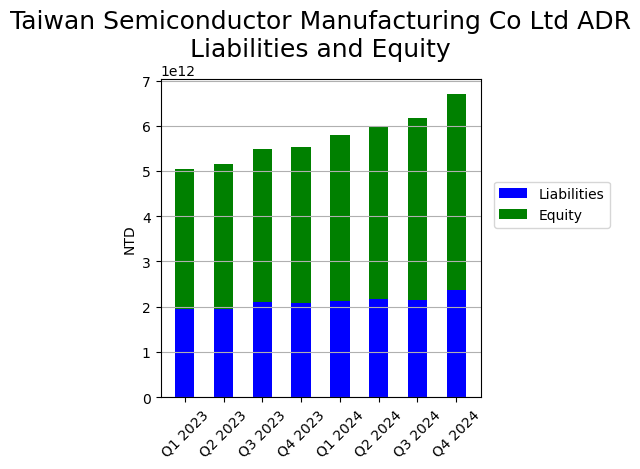

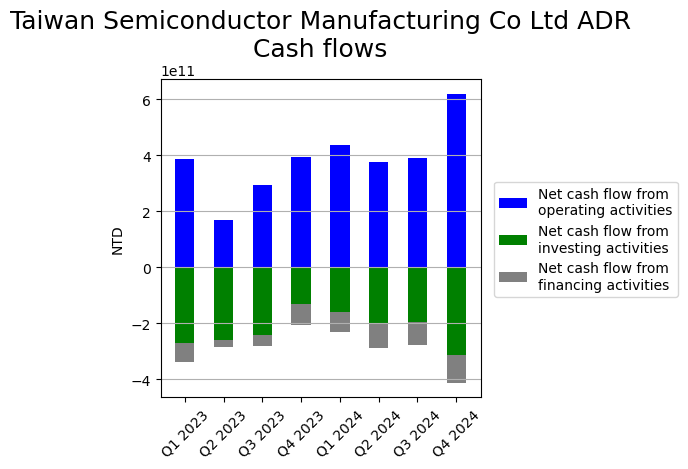

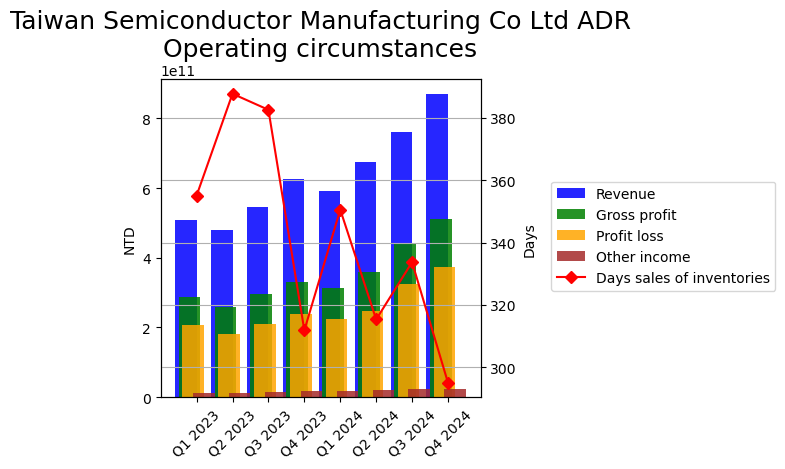

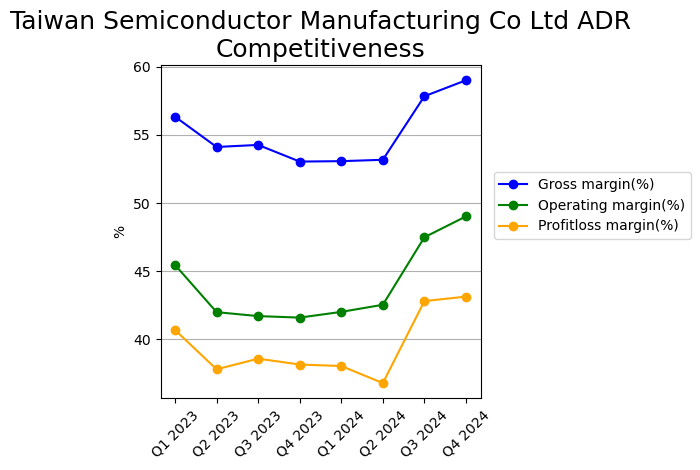

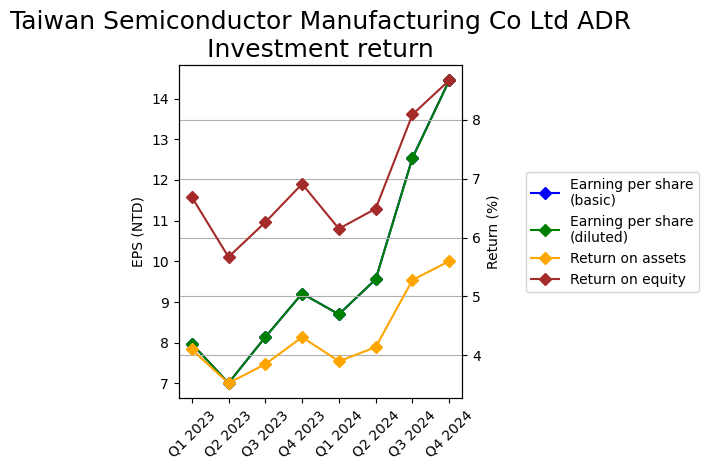

In [13]:
if __name__=="__main__":
  print("American stock analysis from morningstar")
  stock_abbr=input("Please enter stock's abbreviation: ")
  print(stock_abbr)
  try:
    await search_company_from_morningstar(stock_abbr.lower())

    # Test
    # result_dict=extract_data_from_reports(stock_abbr,"company_name")
    # plot_results(result_dict)
  except Exception as e:
    print(e)

## 測試

In [20]:
ttt="ASML"
print(f"{ttt.lower()}")
a1=np.array([2,1,3])
a2=np.array([np.nan,0,3])
a1/a2
type(None)

asml


<ipython-input-20-23c0d9ebc533>:5: RuntimeWarning: divide by zero encountered in divide
  a1/a2


NoneType

In [12]:
!pip install xlrd

   ---------------------------------------- 0.0/96.5 kB ? eta -:--:--
   ---- ----------------------------------- 10.2/96.5 kB ? eta -:--:--
   ---------------- ----------------------- 41.0/96.5 kB 487.6 kB/s eta 0:00:01
   ---------------- ----------------------- 41.0/96.5 kB 487.6 kB/s eta 0:00:01
   ------------------------- -------------- 61.4/96.5 kB 297.7 kB/s eta 0:00:01
   ---------------------------------------- 96.5/96.5 kB 425.1 kB/s eta 0:00:00
